In [ ]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["SimSun"]
plt.rcParams["axes.unicode_minus"] = False
os.chdir('D:\A_Python\跟着黑马学ai\workworkwrokwrok\数模\第二次校赛')
print(os.getcwd())

In [ ]:
df_1 = pd.read_excel('.\data\附件1.xlsx')
df_2 = pd.read_excel('.\data\附件2.xlsx')
df_3 = pd.read_excel('.\data\附件3.xlsx')
df_4 = pd.read_excel('.\data\附件4.xlsx')

In [233]:
df_1

,单品编码,单品名称,分类编码,分类名称
0,102900005115168,牛首生菜,1011010101,花叶类
1,102900005115199,四川红香椿,1011010101,花叶类
2,102900005115625,本地小毛白菜,1011010101,花叶类
3,102900005115748,白菜苔,1011010101,花叶类
4,102900005115762,苋菜,1011010101,花叶类
...,...,...,...,...
246,106958851400125,海鲜菇(袋)(4),1011010801,食用菌
247,106971533450003,海鲜菇(包),1011010801,食用菌
248,106971533455008,海鲜菇(袋)(3),1011010801,食用菌
249,106973223300667,虫草花(盒)(2),1011010801,食用菌


In [232]:
# df_2.drop(df_2[df_2['销售单价(元/千克)'] < 0].index,inplace=True)
df_2

,销售日期,扫码销售时间,单品编码,销量(千克),销售单价(元/千克),销售类型,是否打折销售
0,2020-07-01,09:15:07.924,102900005117056,0.396,7.6,销售,否
1,2020-07-01,09:17:27.295,102900005115960,0.849,3.2,销售,否
2,2020-07-01,09:17:33.905,102900005117056,0.409,7.6,销售,否
3,2020-07-01,09:19:45.450,102900005115823,0.421,10.0,销售,否
4,2020-07-01,09:20:23.686,102900005115908,0.539,8.0,销售,否
...,...,...,...,...,...,...,...
878498,2023-06-30,21:35:13.264,102900005115250,0.284,24.0,销售,否
878499,2023-06-30,21:35:14.358,102900011022764,0.669,12.0,销售,否
878500,2023-06-30,21:35:20.264,102900005115250,0.125,24.0,销售,否
878501,2023-06-30,21:35:21.509,102900011016701,0.252,5.2,销售,否


In [221]:
df_3

,日期,单品编码,批发价格(元/千克)
0,2020-07-01,102900005115762,3.88
1,2020-07-01,102900005115779,6.72
2,2020-07-01,102900005115786,3.19
3,2020-07-01,102900005115793,9.24
4,2020-07-01,102900005115823,7.03
...,...,...,...
55977,2023-06-30,102900051000944,18.00
55978,2023-06-30,102900051004294,6.45
55979,2023-06-30,102900051010455,4.48
55980,2023-06-30,106949711300259,1.45


In [222]:
df_4

,小分类编码,小分类名称,平均损耗率(%)_小分类编码_不同值
0,1011010201,花菜类,15.51
1,1011010402,水生根茎类,13.65
2,1011010101,花叶类,12.83
3,1011010801,食用菌,9.45
4,1011010504,辣椒类,9.24
5,1011010501,茄类,6.68


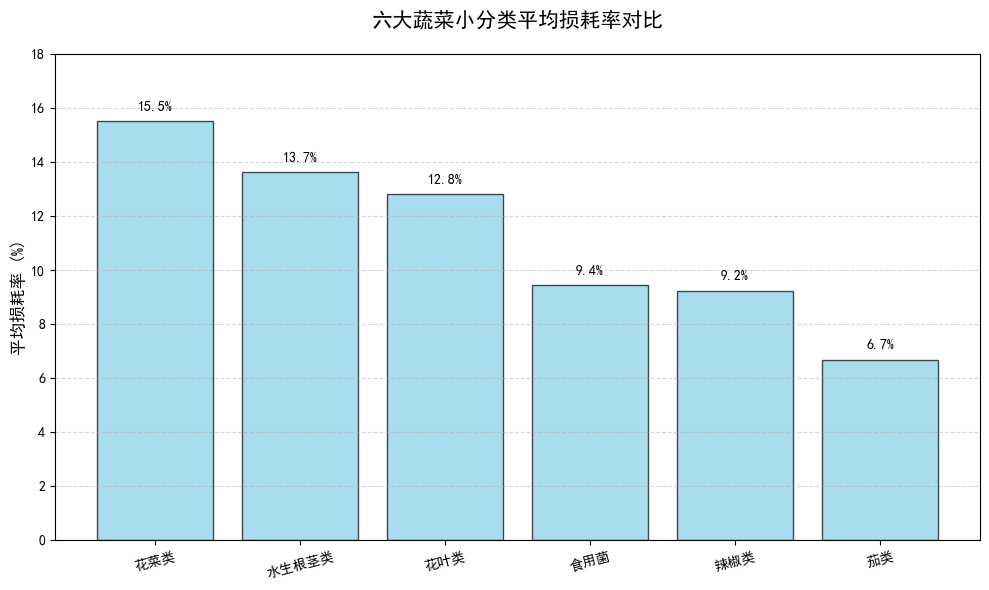

In [226]:
import pandas as pd
import matplotlib.pyplot as plt

# 从图片中提取的数据
data = {
    "小分类编码": [1011010201, 1011010402, 1011010101, 1011010801, 1011010504, 1011010501],
    "小分类名称": ["花菜类", "水生根茎类", "花叶类", "食用菌", "辣椒类", "茄类"],
    "平均损耗率(%)": [15.51, 13.65, 12.83, 9.45, 9.24, 6.68]
}
df = pd.DataFrame(data)
# 设置中文字体（避免乱码）
plt.rcParams['font.sans-serif'] = ['SimHei']  # Windows系统用黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

# 创建画布
plt.figure(figsize=(10, 6))

# 绘制直方图
bars = plt.bar(
    df['小分类名称'],          # x轴：蔬菜类别
    df['平均损耗率(%)'],       # y轴：损耗率
    color='skyblue',          # 统一颜色（或使用列表自定义每个柱子颜色）
    edgecolor='black',         # 边框颜色
    alpha=0.7                  # 透明度
)

# 在柱子上方显示数值
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # x坐标（柱子中心）
        height + 0.3,                        # y坐标（略高于柱子顶部）
        f'{height:.1f}%',                   # 显示数值（保留1位小数）
        ha='center',                         # 水平居中
        va='bottom',                         # 垂直对齐
        fontsize=10
    )

# 设置标题和坐标轴
plt.title('六大蔬菜小分类平均损耗率对比', fontsize=15, pad=20)
plt.ylabel('平均损耗率 (%)', fontsize=12)
plt.ylim(0, 18)  # 调整y轴范围，留出标注空间

# 可选：旋转x轴标签（如果名称过长）
plt.xticks(rotation=15)

# 显示网格线（横向虚线）
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [235]:
merged_df = pd.merge(df_1, df_2, on='单品编码')

stats = merged_df.groupby(['单品名称'])['销量(千克)'].agg(
    ['max','min','std','median','sum', 'mean','skew']
)

# 单独计算峰度
kurt = merged_df.groupby(['单品名称'])['销量(千克)'].apply(pd.Series.kurt)

# 合并结果
category_sales = stats.join(kurt.rename('峰度')).rename(columns={
    'max':'最大值',
    'min':'最小值',
    'std':'标准差',
    'median':'中位数',
    'sum': '总销量',
    # 'count': '销售记录数',
    'mean': '平均销量',
    'skew':'偏度'
})
# category_sales[category_sales['总销量']>8000].round(2).T
category_sales.round(2).T

单品名称,七彩椒(1),七彩椒(2),七彩椒(份),上海青,上海青(份),东门口小白菜,丝瓜尖,云南油麦菜,云南油麦菜(份),云南生菜,...,黄心菜(2),黄白菜(1),黄白菜(2),黄花菜,黑油菜,黑牛肝菌,黑牛肝菌(盒),黑皮鸡枞菌,黑皮鸡枞菌(盒),龙牙菜
最大值,0.83,0.67,1.0,9.00,2.00,1.42,0.86,2.92,2.00,6.00,...,9.60,0.78,16.00,0.26,1.24,0.33,1.0,0.24,1.0,1.83
最小值,0.01,-0.18,1.0,-0.62,-1.00,-0.20,0.26,-0.65,-1.00,-0.72,...,-0.48,-0.33,-0.75,0.06,0.16,0.22,1.0,0.12,1.0,0.18
标准差,0.11,0.12,0.0,0.22,0.04,0.16,0.10,0.17,0.06,0.19,...,0.26,0.13,0.29,0.06,0.19,0.06,0.0,0.03,0.0,0.24
中位数,0.28,0.36,1.0,0.42,1.00,0.35,0.40,0.42,1.00,0.37,...,0.54,0.34,0.50,0.17,0.40,0.27,1.0,0.17,1.0,0.67
总销量,263.19,370.03,18.0,7606.76,3070.00,1543.48,14.23,10305.36,8848.00,15910.46,...,1882.77,155.50,7987.99,1.78,101.12,1.08,4.0,5.80,4.0,186.83
平均销量,0.31,0.35,1.0,0.46,1.00,0.37,0.41,0.44,1.00,0.40,...,0.55,0.35,0.56,0.16,0.42,0.27,1.0,0.17,1.0,0.71
偏度,0.93,-0.08,0.0,4.69,-34.69,1.19,2.59,1.28,-31.24,3.17,...,15.62,-0.01,13.22,-0.28,1.27,0.13,0.0,0.25,0.0,0.75
峰度,0.94,-0.72,0.0,138.23,2087.83,2.78,11.02,5.33,1045.62,57.07,...,492.93,2.31,628.60,-0.67,1.99,-5.24,0.0,-0.59,0.0,1.59


In [ ]:


stats = merged_df.groupby(['分类编码', '分类名称'])['销量(千克)'].agg(
    ['max','min','std','median','sum','count','mean','skew']
)

# 单独计算峰度
kurt = merged_df.groupby(['分类编码', '分类名称'])['销量(千克)'].apply(pd.Series.kurt)

# 合并结果
category_sales = stats.join(kurt.rename('峰度')).rename(columns={
    'max':'最大值',
    'min':'最小值',
    'std':'标准差',
    'median':'中位数',
    'sum': '总销量',
    'count': '销售记录数',
    'mean': '平均销量',
    'skew':'偏度'
})
category_sales.round(2)

In [ ]:
x = category_sales.reset_index('分类名称')['分类名称']
y = merged_df.groupby(['分类编码', '分类名称'])['单品名称'].nunique()

plt.figure(figsize=(5,4),dpi=150)
# plt.bar(x,y,color='skyblue', edgecolor='black')
#
#
plt.pie(
    y,
    labels=x,
    autopct="%1.1f%%",  # 显示百分比
    startangle=150,      # 起始角度（垂直向上）
    wedgeprops={"edgecolor": "white", "linewidth": 1},  # 白色边框
    colors=plt.cm.Pastel1.colors  # 柔和配色
)

plt.xlabel('六大品类蔬菜的品种丰富度占比图',fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
x = category_sales.reset_index('分类名称')['分类名称']
y = category_sales['总销量'].round(2)
plt.figure(figsize=(5,4),dpi=150)
plt.bar(x,y,color='skyblue', edgecolor='black')


# plt.pie(
#     y,
#     labels=x,
#     autopct="%1.1f%%",  # 显示百分比
#     startangle=150,      # 起始角度（垂直向上）
#     wedgeprops={"edgecolor": "white", "linewidth": 1},  # 白色边框
#     colors=plt.cm.Pastel1.colors  # 柔和配色
# )

plt.xlabel('六大蔬菜类别',fontsize=12)
plt.ylabel('总销售量kg',fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
grouped = merged_df.groupby(['销售日期', '分类编码'])['销量(千克)'].sum().unstack(fill_value=0)

# 提取数据（所有日期对齐）
x = grouped.index  # 所有日期
y4 = grouped[1011010501].values  # 茄类
y5 = grouped[1011010504].values  # 辣椒类
y6 = grouped[1011010801].values  # 食用菌

dates = x
categories = [ "茄类", "辣椒类", "食用菌"]

daily_sales = {
    "茄类": y4,
    "辣椒类": y5,
    "食用菌": y6
}

# 2. 面向对象绘图
fig, ax = plt.subplots(figsize=(12, 6))

# 为每个类别绘制折线
colors = plt.cm.Pastel1(np.linspace(0, 1, len(categories)))  # 柔和配色
for idx, category in enumerate(categories):
    ax.plot(
        dates,
        daily_sales[category],
        label=category,
        color=colors[idx],
        linewidth=2,
        markersize=4
    )

# 3. 设置图表属性
ax.set_title("六大蔬菜类别日销售量趋势", fontsize=14, pad=20)
ax.set_xlabel("日期", fontsize=12)
ax.set_ylabel("日销售量 (kg)", fontsize=12)
ax.legend(loc="upper left", frameon=False)
ax.grid(axis="y", linestyle="--", alpha=0.7)

# 4. 优化坐标轴
ax.xaxis.set_tick_params(rotation=45)  # 旋转日期标签

# 5. 显示图表
plt.tight_layout()
plt.show()

In [ ]:
grouped = merged_df.groupby(['销售日期', '分类编码'])['销量(千克)'].sum().unstack(fill_value=0)

# 提取数据（所有日期对齐）
x = grouped.index  # 所有日期
y1 = grouped[1011010101].values  # 花叶类
y2 = grouped[1011010201].values  # 花菜类
y3 = grouped[1011010402].values  # 水生根茎类

dates = x
categories = ["花叶类", "花菜类", "水生根茎类"]

daily_sales = {
    "花叶类": y1,
    "花菜类": y2,
    "水生根茎类":y3,
}

# 2. 面向对象绘图
fig, ax = plt.subplots(figsize=(12, 6))

# 为每个类别绘制折线
colors = plt.cm.Pastel1(np.linspace(0, 1, len(categories)))  # 柔和配色
for idx, category in enumerate(categories):
    ax.plot(
        dates,
        daily_sales[category],
        label=category,
        color=colors[idx],
        linewidth=2,
        markersize=4
    )

# 3. 设置图表属性
ax.set_title("六大蔬菜类别日销售量趋势", fontsize=14, pad=20)
ax.set_xlabel("日期", fontsize=12)
ax.set_ylabel("日销售量 (kg)", fontsize=12)
ax.legend(loc="upper left", frameon=False)
ax.grid(axis="y", linestyle="--", alpha=0.7)

# 4. 优化坐标轴
ax.xaxis.set_tick_params(rotation=45)  # 旋转日期标签

# 5. 显示图表
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

# 确保日期为datetime类型
merged_df['销售日期'] = pd.to_datetime(merged_df['销售日期'])

# 筛选指定时间范围
start_date = '2020-07-01'
end_date = '2023-06-30'
df_filtered = merged_df[(merged_df['销售日期'] >= start_date) & (merged_df['销售日期'] <= end_date)]

# 添加季度列（格式：YYYY-Q1/Q2/Q3/Q4）
df_filtered['季度'] = df_filtered['销售日期'].dt.to_period('Q').astype(str)

# 按季度和分类名称计算平均销量
quarterly_avg = df_filtered.groupby(['季度', '分类名称'])['销量(千克)'].mean().unstack()
# 设置中文字体（解决中文乱码）
plt.rcParams['font.sans-serif'] = ['SimHei']  # Windows
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

# 创建画布
plt.figure(figsize=(14, 7))

# 颜色列表（六大品类）
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

# 绘制每条折线
for i, category in enumerate(quarterly_avg.columns):
    plt.plot(
        quarterly_avg.index,
        quarterly_avg[category],
        label=category,
        color=colors[i],
        linewidth=2,
        markersize=8
    )

# 设置图表标题和坐标轴
plt.title('六大品类蔬菜季度平均销售量趋势（2020Q3-2023Q2）', fontsize=16, pad=20)
plt.xlabel('季度', fontsize=12)
plt.ylabel('平均销售量（千克）', fontsize=12)
plt.xticks(rotation=45)  # 旋转x轴标签

# 添加图例和网格
plt.legend(loc='upper right', frameon=True)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# 调整布局
plt.tight_layout()
plt.show()

In [231]:
import pandas as pd

# 根据图片中的表格数据创建DataFrame
data = {
    "花菜类":    [1.00, 0.00, 0.00, 0.00, 0.00, 0.00],
    "食用菌":    [0.00, 1.00, 0.00, 0.00, 0.00, 0.00],
    "花叶类":    [0.00, 0.00, 1.00, 0.00, 0.00, 0.00],
    "辣椒类":    [0.00, 0.00, 0.00, 1.00, 0.00, 0.00],
    "茄类":      [0.00, 0.00, 0.00, 0.00, 1.00, 0.00],
    "水生根茎类": [0.00, 0.00, 0.00, 0.00, 0.00, 1.00]
}

df_pvalues = pd.DataFrame(
    data,
    index=["花菜类", "食用菌", "花叶类", "辣椒类", "茄类", "水生根茎类"]
)

print("Spearman相关系数检验P值表：")
df_pvalues

Spearman相关系数检验P值表：


,花菜类,食用菌,花叶类,辣椒类,茄类,水生根茎类
花菜类,1.0,0.0,0.0,0.0,0.0,0.0
食用菌,0.0,1.0,0.0,0.0,0.0,0.0
花叶类,0.0,0.0,1.0,0.0,0.0,0.0
辣椒类,0.0,0.0,0.0,1.0,0.0,0.0
茄类,0.0,0.0,0.0,0.0,1.0,0.0
水生根茎类,0.0,0.0,0.0,0.0,0.0,1.0


In [239]:

merged_df = pd.merge(
    df_2,
    df_1[['单品编码', '单品名称', '分类名称']],  # 只保留需要的列
    on='单品编码',
    how='left'
)

# 按单品分组计算指标
result = merged_df.groupby(['单品编码', '单品名称', '分类名称']).agg(
    总销售量_千克=('销量(千克)', 'sum'),
    每日最大销售量_千克=('销量(千克)', 'max'),
    日均销售量_千克=('销量(千克)', 'mean')
).reset_index()

# 按总销售量降序排序
result = result.sort_values('总销售量_千克', ascending=False)

# 打印结果
result

,单品编码,单品名称,分类名称,总销售量_千克,每日最大销售量_千克,日均销售量_千克
97,102900011016701,芜湖青椒(1),辣椒类,28164.331,10.000,0.402664
28,102900005116714,西兰花,花菜类,27537.228,12.487,0.467485
32,102900005116899,净藕(1),水生根茎类,27149.440,13.993,0.691089
17,102900005115960,大白菜,花叶类,19187.218,14.592,1.264147
6,102900005115779,云南生菜,花叶类,15910.461,6.003,0.398888
...,...,...,...,...,...,...
180,102900011033531,红珊瑚(粗叶),花叶类,0.682,0.162,0.136400
220,102900051000890,芥兰,花叶类,0.671,0.671,0.671000
184,102900011033913,紫白菜(2),花菜类,0.615,0.408,0.307500
181,102900011033562,红橡叶,花叶类,0.419,0.182,0.139667


C:\Users\L\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\L\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\L\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\L\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_

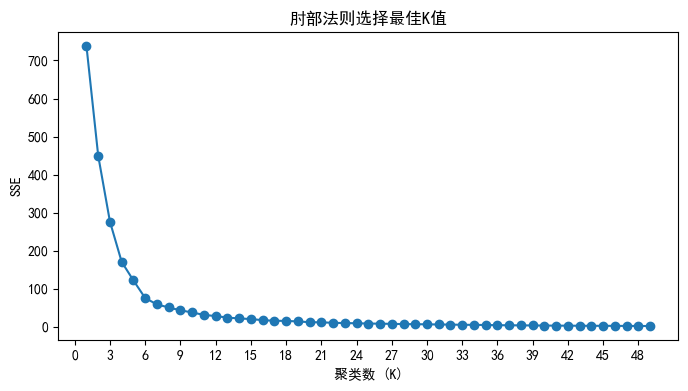

In [244]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# 选择数值特征
X = result[["总销售量_千克", "每日最大销售量_千克", "日均销售量_千克"]]

# 标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 计算不同K值的SSE（误差平方和）
sse = []
for k in range(1, 50):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    sse.append(kmeans.inertia_)

# 绘制肘部曲线
plt.figure(figsize=(8, 4))
plt.plot(range(1, 50), sse, marker='o')
plt.xlabel("聚类数 (K)")
plt.ylabel("SSE")
plt.xticks(range(0,50)[::3])
plt.title("肘部法则选择最佳K值")
plt.show()



C:\Users\L\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\L\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\L\AppData\Local\Temp\ipykernel_22104\4202322449.py:5: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  cluster_max = result.groupby('Cluster')['总销售量_千克','每日最大销售量_千克','日均销售量_千克'].max()


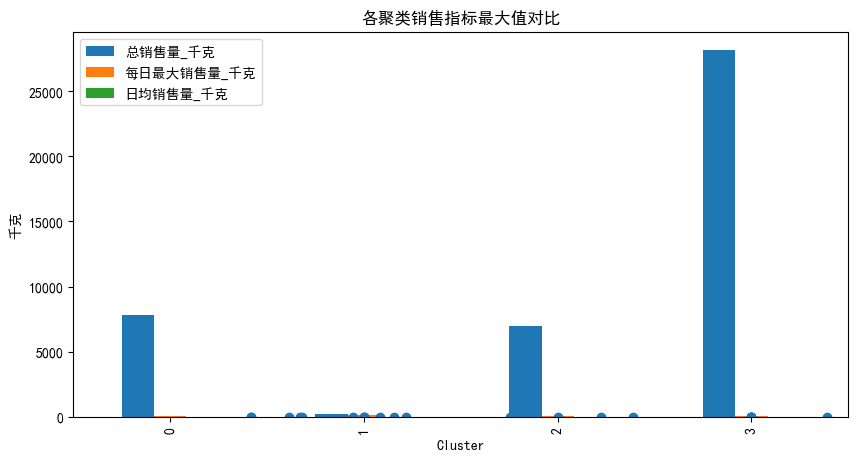

In [268]:
kmeans = KMeans(n_clusters=4)
result["Cluster"] = kmeans.fit_predict(X_scaled)

# 查看聚类结果
cluster_max = result.groupby('Cluster')['总销售量_千克','每日最大销售量_千克','日均销售量_千克'].max()
cluster_max.plot(kind='bar', figsize=(10, 5), title='各聚类销售指标最大值对比')
plt.ylabel('千克')
plt.show()

<Figure size 800x600 with 0 Axes>

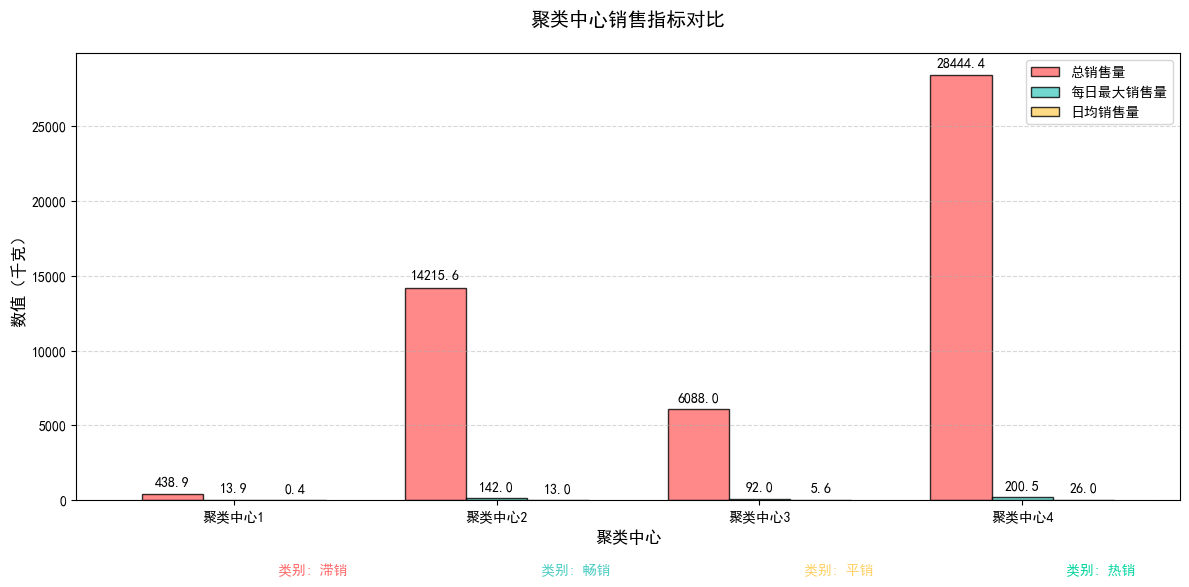

In [272]:
import pandas as pd
import matplotlib.pyplot as plt

# 根据图片中的聚类中心数据创建DataFrame
cluster_centers = pd.DataFrame({
    "聚类中心": ["聚类中心1", "聚类中心2", "聚类中心3", "聚类中心4"],
    "总销售量": [438.8518911, 14215.58056, 6087.9508, 28444.3606],
    "每日最大销售量": [13.93541584, 142.037, 91.985, 200.5386],
    "日均销售量": [0.400777983, 12.98226535, 5.55977242, 25.97658502],
    "类别": ["滞销", "畅销", "平销", "热销"]
})

# 设置索引为聚类中心名称
cluster_centers.set_index("聚类中心", inplace=True)
# 设置画布和颜色
plt.figure(figsize=(8, 6))
colors = ["#FF6B6B", "#4ECDC4", "#FFD166", "#06D6A0"]  # 红/青/黄/绿对应不同类别

# 绘制分组柱状图
ax = cluster_centers[["总销售量", "每日最大销售量", "日均销售量"]].plot(
    kind="bar",
    color=colors,
    width=0.7,
    edgecolor="black",
    alpha=0.8,
    figsize=(12, 6)
)

# 设置图表标题和坐标轴
plt.title("聚类中心销售指标对比", fontsize=14, pad=20)
plt.xlabel("聚类中心", fontsize=12)
plt.ylabel("数值（千克）", fontsize=12)
plt.xticks(rotation=0)  # 保持横轴标签水平

# 添加数据标签
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,
        height + 500,  # 调整标签位置避免重叠
        f"{height:.1f}",
        ha="center",
        fontsize=10
    )

# 添加类别标注（右侧图例）
for i, category in enumerate(cluster_centers["类别"]):
    ax.text(
        i + 0.3,  # 文字x坐标
        -5000,    # 文字y坐标（负值显示在柱子下方）
        f"类别: {category}",
        color=colors[i],
        fontweight="bold",
        ha="center"
    )

# 调整布局
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [269]:
result.groupby('Cluster')['总销售量_千克','每日最大销售量_千克','日均销售量_千克'].max()

C:\Users\L\AppData\Local\Temp\ipykernel_22104\3188040486.py:1: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  result.groupby('Cluster')['总销售量_千克','每日最大销售量_千克','日均销售量_千克'].max()


,总销售量_千克,每日最大销售量_千克,日均销售量_千克
Cluster,,,
0,7792.181,20.0,0.677533
1,200.000,160.0,4.878049
2,6931.000,30.0,4.240891
3,28164.331,25.0,1.264147


In [285]:
result['Cluster'].replace({1:'滞销',2:'平销',0:'畅销',3:'热销'},inplace=True)
result[['单品名称','Cluster']].sort_index().to_excel('./11.xlsx')